# Brain Proton Density Image

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Load the image in Original format
image_rgb = cv2.imread('brain_proton.png')

# Load brain image in grayscale
image_grayscale = cv2.imread('brain_proton.png', cv2.IMREAD_GRAYSCALE)


# Plot images
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_grayscale, cmap='gray')
plt.title('grayscale Image')
plt.axis('off')
plt.show()

: 

(a)White Matter Enhancement

Transformation

In [ ]:
'''Dark Region 0-80  
   Gray Region 80-140 
   White Region 140-255
'''

def intensity_transform_white(intensity):
    if intensity < 80:
        return ((50/80) * intensity)  # compress dark region to 50
    elif 80 <= intensity < 140:
        grad = (255 - 50) / (140 - 80)  # stretch white matter range from 50 to ~200
        return (50 + (intensity - 80) * grad)
    elif 140 <= intensity <= 255:
        grad = (255 - 200) / (255 - 140)  # compress bright region from 200 to 255
        return (200 + (intensity - 140) * grad)
    else:
        return 255
      
# Apply transformation for white matter
white_image = np.zeros_like(image_grayscale)
rows, cols = image_grayscale.shape

for i in range(rows):
    for j in range(cols):
        white_image[i, j] = intensity_transform_white(image_grayscale[i, j])
        


Transformation Curve

Text(0, 0.5, 'Output Intensity')

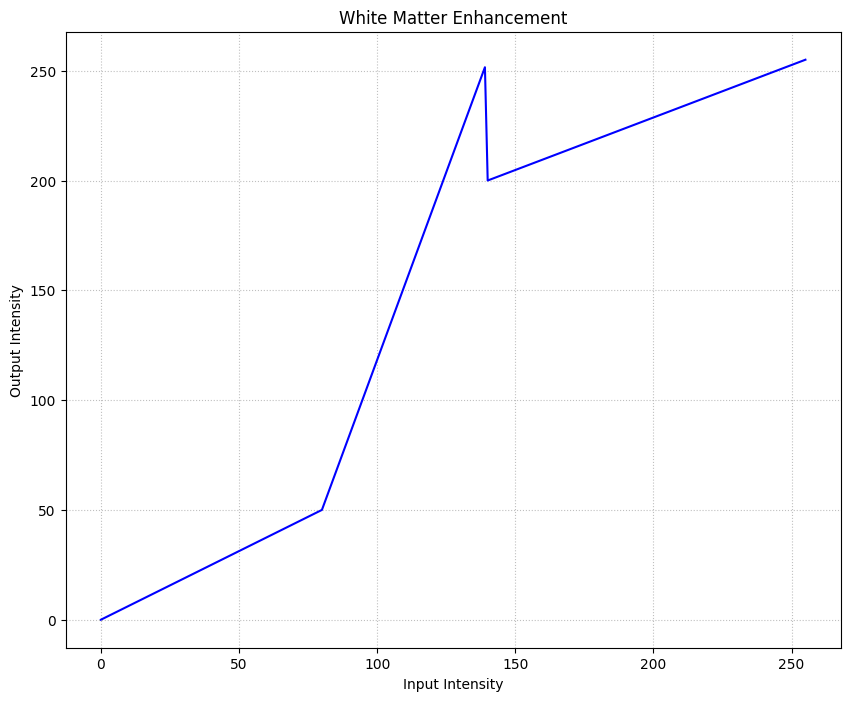

In [60]:
x_vals = np.arange(256)
white_curve = [intensity_transform_white(x) for x in x_vals]

# Plot the transformation curve
plt.figure(figsize=(10,8))
plt.plot(x_vals, white_curve, color='blue')
plt.title("White Matter Enhancement")
plt.grid(True, linestyle=':', alpha=0.8)
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")



Compare Original and White Enhanced Image

(np.float64(-0.5), np.float64(180.5), np.float64(216.5), np.float64(-0.5))

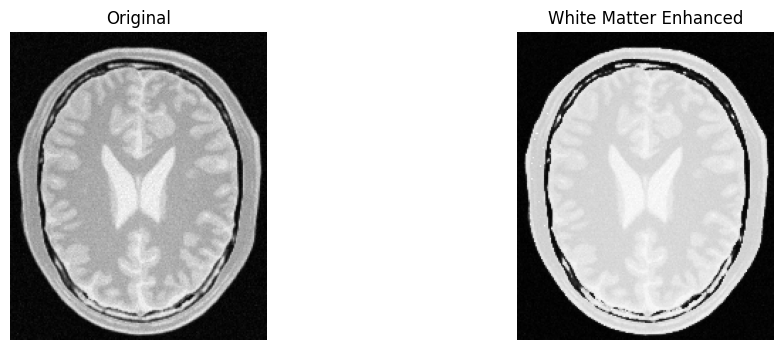

In [61]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(image_grayscale, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(white_image, cmap='gray')
plt.title("White Matter Enhanced")
plt.axis('off')



(b)Black Matter Enhancement

Transformation Curve

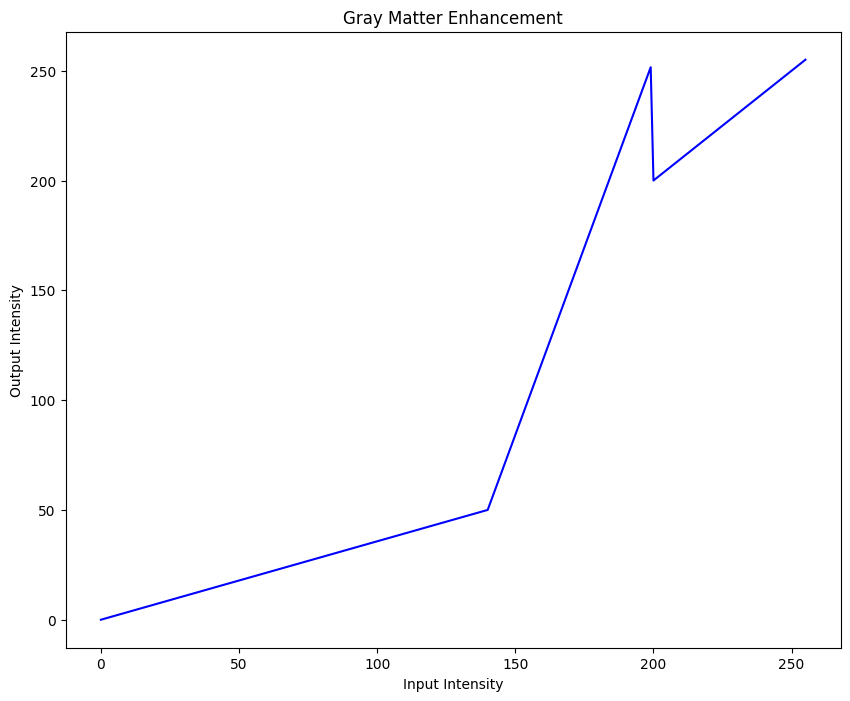

In [ ]:

'''Dark Region 0-140  
   Gray Region 140-200
   White Region 200-255
'''
def intensity_transform_gray(intensity):
    if intensity < 140:
        return ((50/140) * intensity)  # compress dark region to 50
    elif 140 <= intensity < 200:
        grad = (255 - 50) / (200 - 140)  # stretch gray matter range from 50 to 255
        return (50 + (intensity - 140) * grad)
    elif 200 <= intensity <= 255:
        return intensity  # keep bright region unchanged
    else:
        return 255
      
# Apply transformation for gray matter
gray_img = np.zeros_like(image_grayscale)
rows, cols = image_grayscale.shape

for i in range(rows):
    for j in range(cols):
        gray_img[i, j] = intensity_transform_gray(image_grayscale[i, j])
        
# Plot transformation curve
x_vals = np.arange(256)
gray_curve = [intensity_transform_gray(x) for x in x_vals]

plt.figure(figsize=(10,8))
plt.plot(x_vals, gray_curve, color='blue')
plt.title("Gray Matter Enhancement")
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.show()

Compare Original and Gray Enhanced Images

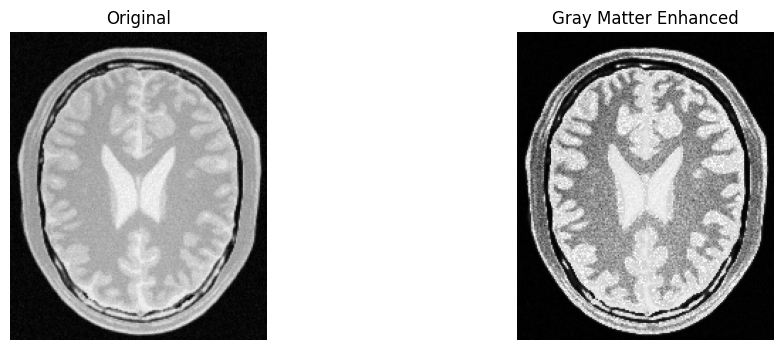

In [52]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(image_grayscale, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gray_img, cmap='gray')
plt.title("Gray Matter Enhanced")
plt.axis('off')

plt.show()
